<div style="background-color:#0A2B07;">
  <h1 style="margin:auto; padding:20px 0; color:#fff; text-align:center; font-weight:bold;">
    PROJET 5 DATA SCIENTIST
  </h1>
  <h2 style="margin:auto; padding:20px 0; color:#fff; text-align:center; font-weight:bold;">
    Segmentez des clients d'un site e-commerce
  </h2>
</div>


## **INITIALISATION**

In [ ]:
# ============================================================
# LIBRAIRIES STANDARD
# ============================================================

from datetime import datetime
import joblib

# ============================================================
# MANIPULATION DE DONNÉES
# ============================================================

import numpy as np
import pandas as pd

# ============================================================
# VISUALISATION
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D

# ============================================================
# MACHINE LEARNING
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


In [2]:
# Définir le dossier où sont stockés les fichiers CSV
data_path = r"C:\Users\barre\Documents\Pro\Reconversion_professionnelle\Formations\Data_Scientist_by_Openclassrooms\P05\data"

# Charger tous les fichiers CSV en utilisant le chemin centralisé
customers = pd.read_csv(f"{data_path}\\olist_customers_dataset.csv")
geolocation = pd.read_csv(f"{data_path}\\olist_geolocation_dataset.csv")
order_items = pd.read_csv(f"{data_path}\\olist_order_items_dataset.csv")
order_payments = pd.read_csv(f"{data_path}\\olist_order_payments_dataset.csv")
order_reviews = pd.read_csv(f"{data_path}\\olist_order_reviews_dataset.csv")
orders = pd.read_csv(f"{data_path}\\olist_orders_dataset.csv")
products = pd.read_csv(f"{data_path}\\olist_products_dataset.csv")
sellers = pd.read_csv(f"{data_path}\\olist_sellers_dataset.csv")


In [4]:
def profile_dataframe(df, table_name, primary_keys=None, verbose=True):
    """
    Profiling complet d'un DataFrame avec informations sur les colonnes
    et éventuellement sur la clé primaire, avec quartiles pour les colonnes numériques et dates.

    Arguments :
        df : DataFrame à analyser
        table_name : nom logique de la table (string)
        primary_keys : dictionnaire {nom_table: [liste_colonnes_identifiants]}
        verbose : bool, si True affiche les infos générales
    
    Retour :
        DataFrame contenant pour chaque colonne :
        - première valeur
        - type pandas
        - type détaillé (numérique, texte, date, booléen)
        - nombre de valeurs uniques
        - % doublons si clé primaire
        - % valeurs manquantes
        - % zéros (numérique)
        - min, max, médiane
        - 1er quartile (25%), 3ème quartile (75%)
        - moyenne (numérique)
    """
    n_rows, n_cols = df.shape

    # Gestion clé primaire
    pk_cols = []
    n_duplicates = None
    if primary_keys and table_name in primary_keys:
        pk_cols = [c for c in primary_keys[table_name] if c in df.columns]
        if pk_cols:
            n_duplicates = df.duplicated(subset=pk_cols, keep=False).sum()
    
    if verbose:
        print(f"\n=== Table : {table_name} ===")
        print(f"Taille : {n_rows} lignes × {n_cols} colonnes")
        if pk_cols:
            pk_str = "', '".join(pk_cols)
            print(f"Clé primaire : '{pk_str}' → {n_duplicates} doublons")
        else:
            if primary_keys and table_name in primary_keys:
                print("Clé primaire définie dans primary_keys mais colonnes manquantes dans le DataFrame")
            else:
                print("Clé primaire : non renseignée")
    
    results = []
    
    for col in df.columns:
        serie = df[col]
        first_value = serie.iloc[0]
        dtype = serie.dtype

        # type détaillé
        if pd.api.types.is_numeric_dtype(serie):
            detailed_type = "numérique"
        elif pd.api.types.is_bool_dtype(serie):
            detailed_type = "booléen"
        elif pd.api.types.is_datetime64_any_dtype(serie):
            detailed_type = "date"
        else:
            detailed_type = "texte"
        
        n_unique = serie.nunique(dropna=False)
        pct_missing = round(serie.isna().mean() * 100, 2)
        
        if detailed_type == "numérique":
            pct_zeros = round((serie == 0).mean() * 100, 2)
            col_min = serie.min()
            col_max = serie.max()
            median = serie.median()
            mean = round(serie.mean(), 2)
            q25 = serie.quantile(0.25)
            q75 = serie.quantile(0.75)
        elif detailed_type == "date":
            pct_zeros = np.nan
            col_min = serie.min()
            col_max = serie.max()
            median = serie.median()
            mean = np.nan
            q25 = serie.quantile(0.25)
            q75 = serie.quantile(0.75)
        else:
            pct_zeros = np.nan
            col_min = np.nan
            col_max = np.nan
            median = np.nan
            mean = np.nan
            q25 = np.nan
            q75 = np.nan

        pct_duplicates = np.nan
        if col in pk_cols:
            pct_duplicates = round((1 - serie.nunique(dropna=False) / n_rows) * 100, 2)
        
        results.append({
            "column": col,
            "first_value": first_value,
            "dtype": dtype,
            "detailed_type": detailed_type,
            "n_unique": n_unique,
            "pct_duplicates": pct_duplicates,
            "pct_missing": pct_missing,
            "pct_zeros": pct_zeros,
            "min": col_min,
            "q25": q25,
            "median": median,
            "q75": q75,
            "max": col_max,
            "mean": mean
        })

    if verbose:
        print("\n--- Tableau de profil ---")
    
    return pd.DataFrame(results)


In [5]:
def plot_distributions(df, columns, table_name="Table", save_path=None, show_values=False, color_dict=None):
    """
    Affiche la distribution d'une ou plusieurs colonnes d'un DataFrame.

    Arguments :
        df : DataFrame pandas
        columns : liste de colonnes ou une seule colonne (string)
        table_name : nom de la table, affiché dans le titre
        save_path : chemin pour sauvegarder la figure (optionnel, PNG, fond transparent)
        show_values : bool, si True affiche les valeurs au-dessus des barres / boxplots
        color_dict : dict, mapping valeur -> couleur pour barplots catégoriels
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd

    if isinstance(columns, str):
        columns = [columns]

    for col in columns:
        if col not in df.columns:
            print(f"Colonne '{col}' non trouvée dans le DataFrame.")
            continue

        serie = df[col]
        plt.figure(figsize=(14, 5))

        # Déterminer le type
        if pd.api.types.is_numeric_dtype(serie):
            type_col = "numérique"
        elif pd.api.types.is_datetime64_any_dtype(serie):
            type_col = "date"
        else:
            type_col = "catégoriel"

        # Échapper les underscores pour LaTeX dans le titre
        col_tex = col.replace("_", r"\_")
        table_tex = table_name.replace("_", r"\_")
        title_str = fr"Distribution de la variable $\mathbf{{\mathit{{{col_tex}}}}}$ de la table $\mathbf{{\mathit{{{table_tex}}}}}$ ({type_col})"

        if type_col in ["numérique", "date"]:
            # histogramme + boxplot
            plt.subplot(1, 2, 1)
            if pd.api.types.is_integer_dtype(serie) and serie.nunique() <= 20:
                bins = range(int(serie.min()), int(serie.max()) + 2)
                sns.histplot(serie, bins=bins, kde=False, color="forestgreen")
                plt.xticks(range(int(serie.min()), int(serie.max()) + 1))
            else:
                sns.histplot(serie, bins=30, kde=True, color="forestgreen")
            plt.ylabel("Fréquence")
            plt.xlabel("")
            plt.title(title_str, fontsize=12)

            plt.subplot(1, 2, 2)
            ax = sns.boxplot(x=serie, color="forestgreen")
            plt.xlabel("")
            plt.title("Boxplot", fontsize=12)

            if show_values:
                median = serie.median()
                plt.text(median, 0.5, f"median={median:.2f}", horizontalalignment='center', 
                         verticalalignment='bottom', color='black', fontsize=10)

        else:
            # barplot pour valeurs catégorielles
            counts = serie.value_counts()
            if color_dict:
                colors = [color_dict.get(v, "forestgreen") for v in counts.index]  # vert forêt par défaut
            else:
                colors = ["forestgreen"] * len(counts)
            ax = sns.barplot(x=counts.index, y=counts.values, palette=colors)
            plt.ylabel("Fréquence")
            plt.xlabel("")
            plt.xticks(rotation=45)
            plt.title(title_str, fontsize=12)

            if show_values:
                for i, v in enumerate(counts.values):
                    ax.text(i, v + max(counts.values)*0.01, str(v), ha='center', fontsize=9)

        plt.tight_layout(rect=[0, 0, 1, 0.9])

        if save_path:
            plt.savefig(save_path, transparent=True)
        plt.show()


# color_segment = {
#     "loyaux": "#2851FF",
#     "loyalistes potentiels": "#092AAE",
#     "Champions": "#15C574",
#     "a réactiver": "#1D8C56",
#     "perdus": "#910909",
#     "a risque": "#E72C26"
# }
# plot_distributions(rfm_v2, ["segment"], table_name="rfm_v2", show_values=True, color_dict=color_segment)


In [7]:
def value_frequencies(df, column):
    """
    Affiche un tableau avec la fréquence des valeurs uniques d'une colonne.
    """
    if column not in df.columns:
        print(f"Colonne '{column}' non trouvée dans le DataFrame.")
        return
    
    freqs = df[column].value_counts(dropna=False)
    freq_table = pd.DataFrame({
        "valeur": freqs.index,
        "fréquence": freqs.values,
        "pourcentage": (freqs.values / len(df) * 100).round(2)
    })
    return freq_table


# **TODO**

| Étape | Objectif | Actions concrètes | Référentiel CE associé | Avancement |
|-------|----------|-----------------|----------------------|-----------|
| 1. Sélection des features | Choisir les variables pertinentes pour le clustering | - Vérifier la qualité et la variance des variables<br>- Retirer les colonnes redondantes ou peu discriminantes<br>- S’assurer que les variables catégorielles sont encodées et les variables continues normalisées | CE1, CE2, CE3, CE4 | ✅ Terminé |
| 2. Prétraitement | Préparer le dataset pour l’algorithme | - Remplacer les NaN si nécessaire ou filtrer<br>- Appliquer StandardScaler ou MinMaxScaler sur les variables continues<br>- Vérifier les variables binaires et one-hot | CE1, CE3, CE4 | ✅ Terminé (df_cluster prêt) |
| 3. Clustering initial | Se familiariser avec l’algorithme | - Lancer un k-means avec 3 à 6 clusters<br>- Observer les résultats initiaux | CE5, CE6, CE8 | ⬜ Pas encore fait |
| 4. Choix du nombre optimal de clusters | Déterminer le nombre de clusters pertinent | - Méthode data-driven : silhouette, elbow, gap statistic<br>- Méthode métier : cohérence avec le business et la lisibilité | CE6, CE1 | ⬜ Pas encore fait |
| 5. Évaluation du clustering | Mesurer la qualité du modèle | - Calculer silhouette score et inertia<br>- Vérifier la stabilité à plusieurs initialisations (random_state)<br>- Analyser la répartition des clusters | CE1, CE2, CE3, CE4, CE5 | ⬜ Pas encore fait |
| 6. Interprétation des clusters | Caractériser les clusters en lien avec les features | - Calculer les moyennes, médianes et distributions par cluster<br>- Identifier les comportements typiques pour chaque cluster | CE5, CE6 | ⬜ Pas encore fait |
| 7. Comparaison d’algorithmes | Tester différentes méthodes | - KMeans vs Agglomerative / DBSCAN (si pertinent)<br>- Comparer scores et stabilité | CE9, CE2, CE4, CE5 | ⬜ Pas encore fait |
| 8. Validation métier | S’assurer que le clustering est compréhensible et exploitable | - Vérifier la tangibilité des clusters pour le business<br>- Ajuster le nombre de clusters ou les features si nécessaire | CE5, CE6 | ⬜ Pas encore fait |
| 9. Stratégie nouveaux clients | Définir comment assigner de nouveaux clients | - Standardiser les nouvelles données avec les mêmes transformations<br>- Affecter le cluster le plus proche (distance euclidienne ou centroid) | CE7, CE8 | ⬜ Pas encore fait |
| 10. Documentation et maintenance | Assurer la traçabilité et reproductibilité | - Commenter le code<br>- Respecter PEP8<br>- Documenter les choix d’algorithme, hyper-paramètres et features | CE7, CE9 | ⬜ Pas encore fait |

# **CADRAGE**

**Objectif métier de la segmentation**
- Identifier des groupes de clients homogènes pour adapter les actions marketing

**Usage marketing attendu**
- Campagnes ciblées, offres personnalisées, priorisation des clients, relances, fidélisation

**Contraintes**
- Interprétabilité : les segments doivent pouvoir être expliqués aux équipes marketing
- Stabilité : segmentation stable dans le temps pour comparer les clusters
- Recalcul : prévoir la fréquence et la méthode pour mettre à jour la segmentation


# **ANALYSE EXPLORATOIRE ET NETTOYAGE DES DONNÉES**

In [8]:
print('customer', customers.columns.tolist())
print('geolocation', geolocation.columns.tolist())
print('order_items', order_items.columns.tolist())
print('order_payments', order_payments.columns.tolist())
print('order_reviews', order_reviews.columns.tolist())
print('orders', orders.columns.tolist())
print('products', products.columns.tolist())
print('sellers', sellers.columns.tolist())

customer ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']
geolocation ['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']
order_items ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']
order_payments ['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']
order_reviews ['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']
orders ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
products ['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', '

In [9]:
primary_keys = {
    "customers": ["customer_unique_id"],
    "geolocation": ["geolocation_zip_code_prefix", "geolocation_city"],
    "order_items": ["order_id", "order_item_id"],
    "order_payments": ["order_id", "payment_sequential"],
    "order_reviews": ["review_id"],
    "orders": ["order_id"],
    "products": ["product_id"],
    "sellers": ["seller_id"]
}

### **CUSTOMER**

In [10]:
# # Suppression des doublons sur customer_unique_id
# # customers = customers.drop_duplicates(subset=['customer_unique_id'], keep='first')

# # Affichage du profil
# profile_customers = profile_dataframe(customers, "customers", primary_keys)
# display(profile_customers)

# # Affichage de la distribution
# plot_distributions(customers, "customer_state", table_name="customers")

### **GEOLOCALISATION**

In [11]:
# Suppression des doublons
geolocation = geolocation.drop_duplicates(subset=['geolocation_zip_code_prefix', 'geolocation_city'], keep='first')

# # Affichage du profil
# profile_geolocation = profile_dataframe(geolocation, "geolocation", primary_keys)
# # display(profile_geolocation)

# # Affichage de la distribution
# plot_distributions(geolocation, "geolocation_state", table_name="geolocation")

### **ORDER_ITEMS**

In [12]:
# Conversion des colonnes de date
cols_to_convert = ['shipping_limit_date']
order_items[cols_to_convert] = order_items[cols_to_convert].apply(pd.to_datetime, format='%Y-%m-%d %H:%M:%S', errors='coerce')

# # Affichage du profil
# profile_order_items = profile_dataframe(order_items, "order_items", primary_keys)
# display(profile_order_items)

# # Affichage de la distribution
# plot_distributions(order_items, ["price", "freight_value", "order_item_id"], table_name="order_items")

### **ORDER_PAYMENTS**

In [13]:
# # Affichage du profil
# profile_order_payments = profile_dataframe(order_payments, "order_payments", primary_keys)
# display(profile_order_payments)

# # Affichage de la distribution
# plot_distributions(order_payments, ["payment_sequential", "payment_type", "payment_value"], table_name="order_payments")

### **ORDER_REVIEW**

In [14]:
# Suppression des doublons sur review_id
# order_reviews = order_reviews.drop_duplicates(subset=['review_id'], keep='first')

# Conversion des colonnes de date
cols_to_convert = ['review_creation_date', 'review_answer_timestamp']
order_reviews[cols_to_convert] = order_reviews[cols_to_convert].apply(
    pd.to_datetime, format='%Y-%m-%d %H:%M:%S', errors='coerce'
)

# # Affichage du profil
# profile_order_reviews = profile_dataframe(order_reviews, "order_reviews", primary_keys)
# display(profile_order_reviews)

# # Affichage de la distribution
# plot_distributions(order_reviews, "review_score", table_name="order_reviews")


### **ORDERS**

In [15]:
# Conversion des colonnes de date
cols_to_convert_orders = ['order_purchase_timestamp', 'order_approved_at', 
                          'order_delivered_carrier_date', 'order_delivered_customer_date', 
                          'order_estimated_delivery_date']
orders[cols_to_convert_orders] = orders[cols_to_convert_orders].apply(
    pd.to_datetime, format='%Y-%m-%d %H:%M:%S', errors='coerce'
)

# # Affichage du profil
# profile_orders = profile_dataframe(orders, "orders", primary_keys)
# display(profile_orders)

# # Affichage de la distribution
# plot_distributions(orders, ["order_status", "order_purchase_timestamp", "order_delivered_customer_date"], table_name="orders")

### **PRODUCTS**

In [16]:
# # Affichage du profil
# profile_products = profile_dataframe(products, "products", primary_keys)
# display(profile_products)

# # Affichage de la distribution
# plot_distributions(products, ["product_weight_g", "product_length_cm"], table_name="products")

In [17]:
# value_frequencies(products, "product_category_name")

### **SELLERS**

In [18]:
# # Affichage du profil
# profile_sellers = profile_dataframe(sellers, "sellers", primary_keys)
# display(profile_sellers)

# # Affichage de la distribution
# plot_distributions(sellers, "seller_state", table_name="sellers")

# **K-MEANS_V1**

### **FEATURE ENGINEERING**

In [19]:
# ============================================================
# 1. AGRÉGATION AU NIVEAU COMMANDE (MONETARY)
# ============================================================

order_value = (
    order_items
    .groupby('order_id', as_index=False)
    .agg(
        order_total_value=('price', 'sum'),
        freight_total=('freight_value', 'sum')
    )
)

# Montant total commande = produits + frais de port
order_value['order_total_value'] += order_value['freight_total']


# ============================================================
# 2. ENRICHISSEMENT DES COMMANDES
# ============================================================

orders_rfm = (
    orders
    .merge(order_value, on='order_id', how='left')
    .merge(
        customers[['customer_id', 'customer_unique_id']],
        on='customer_id',
        how='left'
    )
)

orders_rfm['order_purchase_timestamp'] = pd.to_datetime(
    orders_rfm['order_purchase_timestamp']
)


# ============================================================
# 3. AGRÉGATION CLIENT — VARIABLES RFM
# ============================================================

df_rfm = (
    orders_rfm
    .groupby('customer_unique_id', as_index=False)
    .agg(
        frequency=('order_id', 'nunique'),                 # Nombre de commandes
        monetary=('order_total_value', 'sum'),             # Dépense totale
        last_order_date=('order_purchase_timestamp', 'max')
    )
)


# ============================================================
# 4. CALCUL DE LA RECENCY
# ============================================================

# Date de référence = dernière date de commande du dataset
reference_date = df_rfm['last_order_date'].max()

df_rfm['recency'] = (
    reference_date - df_rfm['last_order_date']
).dt.days


# ============================================================
# 5. TABLE FINALE RFM
# ============================================================

df_rfm = df_rfm[[
    'customer_unique_id',
    'frequency',
    'recency',
    'monetary'
]]


In [20]:
# ==============================
# PROFIL
# ==============================

# --- Profil du dataframe ---
profile_df_rfm = profile_dataframe(
    df_rfm,
    table_name="df_rfm",
    primary_keys=primary_keys
)
display(profile_df_rfm)

# --- Sélection des variables pertinentes pour les distributions ---
distribution_cols = (
    df_rfm
    .select_dtypes(include=["int64", "float64"])
    .loc[:, lambda df: df.nunique() > 2]                 # enlève constantes / quasi constantes
    .loc[:, lambda df: df.isna().mean() < 0.3]           # enlève colonnes trop manquantes
    .columns
    .tolist()
)

# --- Exclure les variables binaires (0/1) ---
distribution_cols = [
    col for col in distribution_cols
    if not set(df_rfm[col].dropna().unique()).issubset({0, 1})
]

# --- Affichage des distributions ---
# plot_distributions(
#     df_rfm,
#     distribution_cols,
#     table_name="df_rfm"
# )



=== Table : df_rfm ===
Taille : 96096 lignes × 4 colonnes
Clé primaire : non renseignée

--- Tableau de profil ---


,column,first_value,dtype,detailed_type,n_unique,pct_duplicates,pct_missing,pct_zeros,min,q25,median,q75,max,mean
0,customer_unique_id,0000366f3b9a7992bf8c76cfdf3221e2,object,texte,96096,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,frequency,1,int64,numérique,9,NaN,0.0,0.0,1.0,1.00,1.00,1.0000,17.00,1.03
2,recency,160,int64,numérique,630,NaN,0.0,0.0,0.0,163.00,268.00,397.0000,772.00,287.74
3,monetary,141.9,float64,numérique,31718,NaN,0.0,0.7,0.0,62.39,107.27,182.2375,13664.08,164.87


### **ENTRAÎNEMENT**

In [21]:
# ==============================
# PRÉPARATION DES DONNÉES POUR K-MEANS
# ==============================

# --- Copie de travail ---
df_k_means_v1 = df_rfm.copy()

# --- Exclusion explicite de l'identifiant ---
id_col = 'customer_unique_id'
df_k_means_v1 = df_k_means_v1.drop(columns=[id_col])

# --- Sélection uniquement des colonnes numériques ---
df_k_means_v1 = df_k_means_v1.select_dtypes(include=['int64', 'float64'])

# --- Standardisation des variables RFM ---
scaler = StandardScaler()
df_k_means_v1.loc[:, :] = scaler.fit_transform(df_k_means_v1)

# --- Vérification finale ---
print("Shape df_k_means_v1 :", df_k_means_v1.shape)

profile_df_k_means_v1 = profile_dataframe(
    df_k_means_v1,
    "df_k_means_v1",
    primary_keys=None
)
display(profile_df_k_means_v1)

Shape df_k_means_v1 : (96096, 3)

=== Table : df_k_means_v1 ===
Taille : 96096 lignes × 3 colonnes
Clé primaire : non renseignée

--- Tableau de profil ---


C:\Users\barre\AppData\Local\Temp\ipykernel_15664\85560586.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.16236828 -0.16236828 -0.16236828 ... -0.16236828 -0.16236828
 -0.16236828]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_k_means_v1.loc[:, :] = scaler.fit_transform(df_k_means_v1)
C:\Users\barre\AppData\Local\Temp\ipykernel_15664\85560586.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.83262149 -0.81306654  1.93766244 ...  2.14624852 -0.78047497
  1.59219173]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_k_means_v1.loc[:, :] = scaler.fit_transform(df_k_means_v1)


,column,first_value,dtype,detailed_type,n_unique,pct_duplicates,pct_missing,pct_zeros,min,q25,median,q75,max,mean
0,frequency,-0.162368,float64,numérique,9,NaN,0.0,0.0,-0.162368,-0.162368,-0.162368,-0.162368,74.470541,-0.0
1,recency,-0.832621,float64,numérique,630,NaN,0.0,0.0,-1.875552,-0.813067,-0.128643,0.712219,3.156587,0.0
2,monetary,-0.100783,float64,numérique,31227,NaN,0.0,0.0,-0.723322,-0.449606,-0.252710,0.076185,59.223294,-0.0


In [ ]:
# # ==============================
# # SILOUETTE SCORE
# # ==============================

# # --- Paramètres ---
# range_n_clusters = range(2, 8)
# silhouette_scores = []
# random_state = 42  # Pour reproductibilité

# # Préparer les données pour le clustering (ignore colonne cluster si elle existe)
# df_for_clustering = df_k_means_v1.drop(columns=['cluster_init'], errors='ignore')

# # --- Calcul des scores silhouette ---
# for k in range_n_clusters:
#     kmeans = KMeans(n_clusters=k, random_state=random_state)
#     labels = kmeans.fit_predict(df_for_clustering)
#     score = silhouette_score(df_for_clustering, labels)
#     silhouette_scores.append(score)

# # --- Affichage de la courbe ---
# plt.figure(figsize=(6,4))
# plt.plot(
#     range_n_clusters,
#     silhouette_scores,
#     marker='o',
#     color='darkgreen'  # <-- couleur vert sapin
# )
# plt.title("Silhouette score en fonction du nombre de clusters")
# plt.xlabel("Nombre de clusters")
# plt.ylabel("Silhouette score")
# plt.grid(True)
# plt.show()

# # --- Tableau des résultats ---
# results_df = pd.DataFrame({
#     "n_clusters": list(range_n_clusters),
#     "silhouette_score": silhouette_scores
# })
# display(results_df)

# # --- Meilleur nombre de clusters selon silhouette ---
# best_k = results_df.loc[results_df['silhouette_score'].idxmax(), 'n_clusters']
# print("Nombre optimal de clusters selon silhouette :", best_k)


n_clusters	silhouette_score

0	2	0.734130

1	3	0.454816

2	4	0.487504

3	5	0.417231

4	6	0.436395

5	7	0.445165

Nombre optimal de clusters selon silhouette : 2

In [ ]:
# ==============================
# K-MEANS À 2 CLUSTERS
# ==============================

n_clusters_2 = 2
random_state = 42

# --- Fit KMeans 2 clusters ---
kmeans_rfm_2_clusters = KMeans(n_clusters=n_clusters_2, random_state=random_state)
df_k_means_v1['cluster'] = kmeans_rfm_2_clusters.fit_predict(df_k_means_v1.drop(columns=['cluster_init'], errors='ignore'))

# --- Vérifications quantitatives ---
inertia = kmeans_rfm_2_clusters.inertia_
sil_score = silhouette_score(df_k_means_v1.drop(columns=['cluster_init', 'cluster'], errors='ignore'), 
                             df_k_means_v1['cluster'])

print(f"Inertia (somme des distances au centre) : {inertia:.2f}")
print(f"Silhouette score : {sil_score:.3f}")

# --- Distribution des clusters ---
print("\nDistribution des clusters :")
print(df_k_means_v1['cluster'].value_counts())


Inertia (somme des distances au centre) : 208205.30
Silhouette score : 0.734

Distribution des clusters :
cluster
0    93088
1     3008
Name: count, dtype: int64


In [32]:
# ==============================
# SAUVEGARDE DATAFRAME ET MODELE K-MEANS
# ==============================

# chemin raw string
path_data = r"C:\Users\barre\Documents\Pro\Reconversion_professionnelle\Formations\Data_Scientist_by_Openclassrooms\P05\data"

# sauvegarde du DataFrame
df_k_means_v1.to_csv(f"{path_data}/df_k_means_v1.csv", index=False)

# sauvegarde du modèle KMeans
joblib.dump(kmeans_rfm_2_clusters, f"{path_data}/kmeans_rfm_2_clusters.joblib")


['C:\\Users\\barre\\Documents\\Pro\\Reconversion_professionnelle\\Formations\\Data_Scientist_by_Openclassrooms\\P05\\data/kmeans_rfm_2_clusters.joblib']

In [33]:
# ==============================
# RECHARGEMENT DATAFRAME ET MODELE K-MEANS
# ==============================

path_data = r"C:\Users\barre\Documents\Pro\Reconversion_professionnelle\Formations\Data_Scientist_by_Openclassrooms\P05\data"

# rechargement du DataFrame
df_k_means_v1 = pd.read_csv(f"{path_data}/df_k_means_v1.csv")

# rechargement du modèle
kmeans_rfm_2_clusters = joblib.load(f"{path_data}/kmeans_rfm_2_clusters.joblib")


In [24]:
# # ==============================
# # K-MEANS À 4 CLUSTERS
# # ==============================

# n_clusters_4 = 4
# random_state = 42

# # --- Fit KMeans 4 clusters ---
# kmeans_rfm_4_clusters = KMeans(n_clusters=n_clusters_4, random_state=random_state)
# df_k_means_v1['cluster'] = kmeans_rfm_4_clusters.fit_predict(df_k_means_v1.drop(columns=['cluster_init'], errors='ignore'))

# # --- Vérifications quantitatives ---
# inertia = kmeans_rfm_4_clusters.inertia_
# sil_score = silhouette_score(df_k_means_v1.drop(columns=['cluster_init', 'cluster'], errors='ignore'), 
#                              df_k_means_v1['cluster'])

# print(f"Inertia (somme des distances au centre) : {inertia:.2f}")
# print(f"Silhouette score : {sil_score:.3f}")

# # --- Distribution des clusters ---
# print("\nDistribution des clusters :")
# print(df_k_means_v1['cluster'].value_counts())

Inertia (somme des distances au centre) : 95768.48

Silhouette score : 0.487

Distribution des clusters :

cluster

0    52065

1    38591

2     2963

3     2477

Name: count, dtype: int64

### **INTERPRÉTATION DES CLUSTERS**


=== Table : df_k_means_v1 ===
Taille : 96096 lignes × 4 colonnes
Clé primaire : non renseignée

--- Tableau de profil ---


,column,first_value,dtype,detailed_type,n_unique,pct_duplicates,pct_missing,pct_zeros,min,q25,median,q75,max,mean
0,frequency,-0.162368,float64,numérique,9,NaN,0.0,0.00,-0.162368,-0.162368,-0.162368,-0.162368,74.470541,-0.00
1,recency,-0.832621,float64,numérique,630,NaN,0.0,0.00,-1.875552,-0.813067,-0.128643,0.712219,3.156587,0.00
2,monetary,-0.100783,float64,numérique,30586,NaN,0.0,0.00,-0.723322,-0.449606,-0.252710,0.076185,59.223294,-0.00
3,cluster,0.000000,int64,numérique,2,NaN,0.0,96.87,0.000000,0.000000,0.000000,0.000000,1.000000,0.03


,recency,monetary,frequency
cluster,,,
0,0.00,-0.02,-0.16
1,-0.13,0.72,5.02


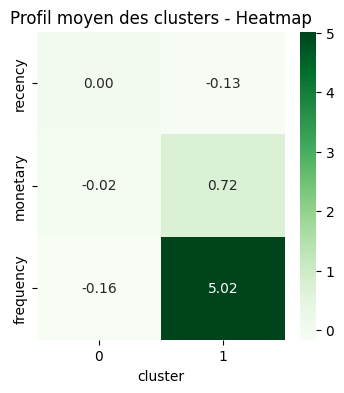

In [94]:
# ==============================
# PROFIL DU DATAFRAME
# ==============================

# Profil complet du dataframe
df_profile = profile_dataframe(df_k_means_v1, table_name="df_k_means_v1")
display(df_profile)

# Profil moyen par cluster pour toutes les variables continues
cols_continuous = ['recency', 'monetary', 'frequency', 'review_score']
cols_continuous = [c for c in cols_continuous if c in df_k_means_v1.columns]

cluster_means = df_k_means_v1.groupby('cluster')[cols_continuous].mean().round(2)
display(cluster_means)

# Heatmap du profil moyen
plt.figure(figsize=(4, 4))
sns.heatmap(cluster_means.T, annot=True, fmt=".2f", cmap="Greens")
plt.title("Profil moyen des clusters - Heatmap")
plt.show()


,cluster,nb_clients
0,0,93088
1,1,3008


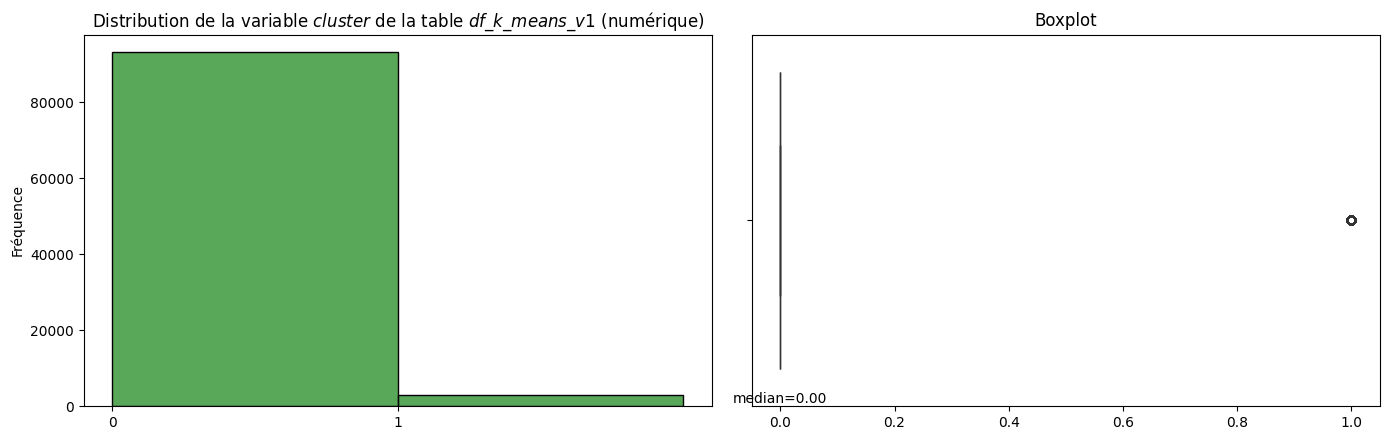

In [95]:
# ==============================
# 2. RÉPARTITION DES CLIENTS
# ==============================

# Tableau chiffré des effectifs
cluster_counts = df_k_means_v1['cluster'].value_counts().sort_index().reset_index()
cluster_counts.columns = ['cluster', 'nb_clients']
display(cluster_counts)

# Barplot forestgreen
plot_distributions(
    df=df_k_means_v1,
    columns='cluster',
    table_name="df_k_means_v1",
    show_values=True
)


cluster,0,1
count,93088.00,3008.00
mean,0.00,-0.13
std,1.00,0.95
min,-1.88,-1.88
25%,-0.81,-0.89
50%,-0.12,-0.26
75%,0.72,0.52
max,3.16,2.95


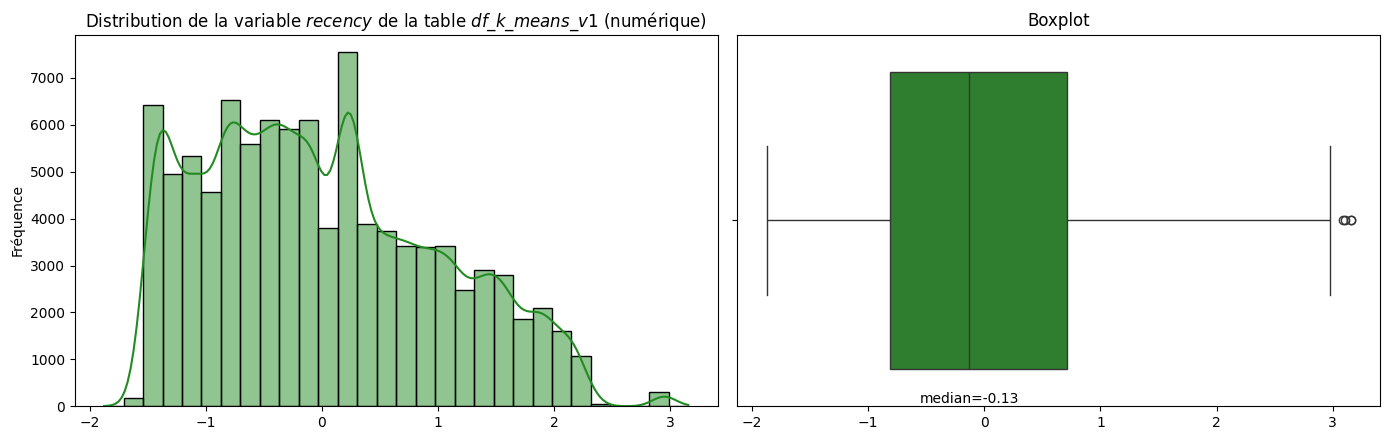

cluster,0,1
count,93088.00,3008.00
mean,-0.02,0.72
std,0.92,2.27
min,-0.72,-0.72
25%,-0.45,-0.09
50%,-0.26,0.26
75%,0.05,0.86
max,17.68,59.22


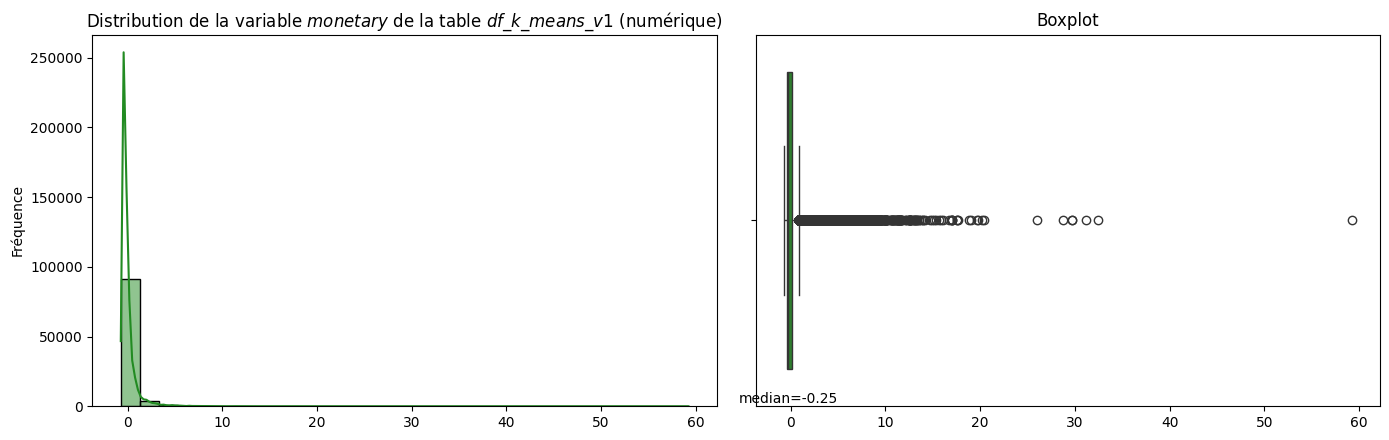

cluster,0,1
count,93088.00,3008.00
mean,-0.16,5.02
std,0.00,2.43
min,-0.16,-0.16
25%,-0.16,4.50
50%,-0.16,4.50
75%,-0.16,4.50
max,-0.16,74.47


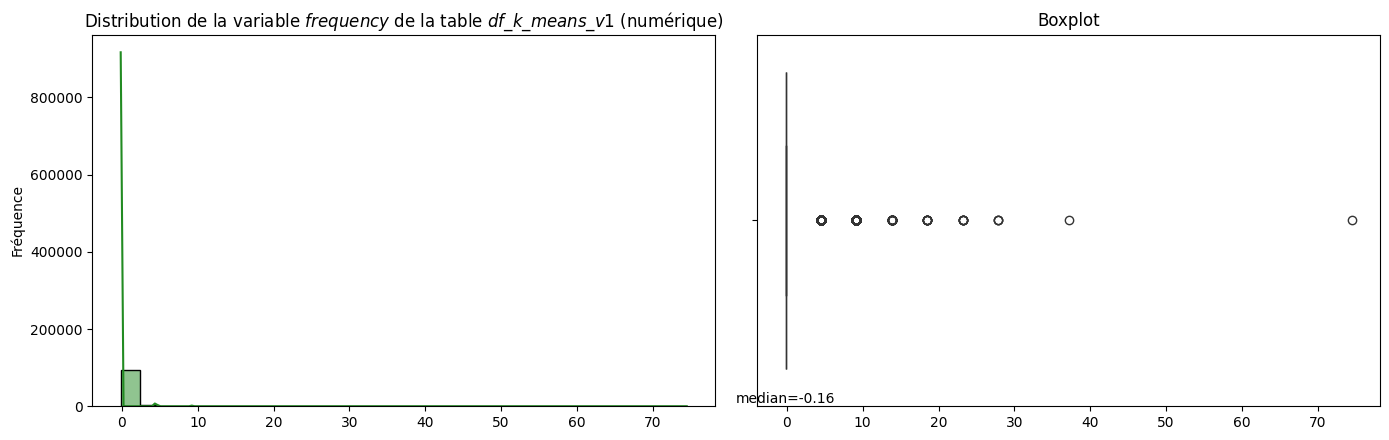

In [96]:
# ==============================
# 3. DISTRIBUTIONS DES VARIABLES
# ==============================

features_to_plot = ['recency', 'monetary', 'frequency']
features_to_plot = [f for f in features_to_plot if f in df_k_means_v1.columns]

# Boucle boxplots + tableau chiffré
for feature in features_to_plot:
    # Tableau descriptif par cluster
    desc = df_k_means_v1.groupby('cluster')[feature].describe().T.round(2)
    display(desc)

    # Boxplot
    plot_distributions(
        df=df_k_means_v1,
        columns=feature,
        table_name="df_k_means_v1",
        show_values=True
    )


afficher les 3 variables en 3D

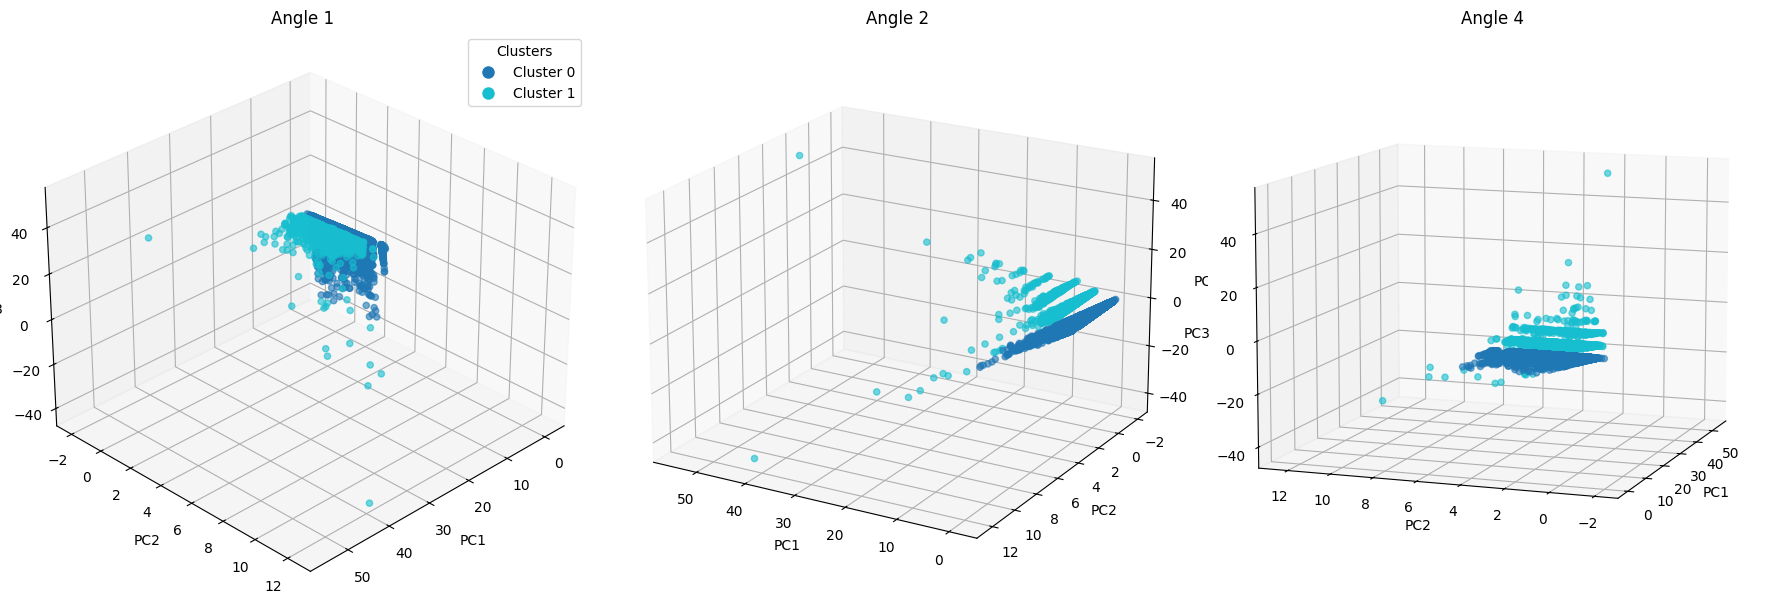

,composante,variance_expliquee,variance_cumulee
0,PC1,0.375,0.375
1,PC2,0.333,0.708
2,PC3,0.292,1.000


,PC1,PC2,PC3
frequency,0.703,0.045,0.710
recency,-0.172,0.979,0.108
monetary,0.690,0.198,-0.696


,PC1,PC2,PC3
cluster,,,
0,-0.13,-0.01,-0.10
1,4.05,0.24,3.05


In [97]:
# ==============================
# 4. PCA 3D + TABLEAUX CHIFFRÉS
# ==============================

X = df_k_means_v1.drop(columns=['cluster', 'cluster_init'], errors='ignore')

# --- PCA ---
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)

# --- VISUALISATION 3D ---
categorical_cmap = plt.cm.tab10

angles = [
    (30, 45, "Angle 1"),
    (20, 120, "Angle 2"),
    (10, 200, "Angle 4")
]

fig = plt.figure(figsize=(18,6))

for i, (elev, azim, title) in enumerate(angles, start=1):
    ax = fig.add_subplot(1, 3, i, projection='3d')
    
    scatter = ax.scatter(
        X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
        c=df_k_means_v1['cluster'],
        cmap=categorical_cmap,
        alpha=0.6
    )
    
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_zlabel("PC3")
    ax.set_title(title)
    ax.view_init(elev=elev, azim=azim)

    if i == 1:
        unique_labels = np.sort(df_k_means_v1['cluster'].unique())
        legend_elements = [
            Line2D(
                [0], [0],
                marker='o',
                color='w',
                markerfacecolor=categorical_cmap(j / (len(unique_labels)-1)),
                label=f"Cluster {l}",
                markersize=10
            )
            for j, l in enumerate(unique_labels)
        ]
        ax.legend(handles=legend_elements, title="Clusters")

plt.tight_layout()
plt.show()

# --- TABLEAUX CHIFFRÉS ---

# 1. Variance expliquée
pca_variance = pd.DataFrame({
    "composante": ["PC1", "PC2", "PC3"],
    "variance_expliquee": pca.explained_variance_ratio_,
    "variance_cumulee": np.cumsum(pca.explained_variance_ratio_)
}).round(3)

display(pca_variance)

# 2. Loadings (contribution des variables)
loadings = pd.DataFrame(
    pca.components_.T,
    index=X.columns,
    columns=["PC1", "PC2", "PC3"]
).round(3)

display(loadings)

# 3. Centres des clusters dans l’espace PCA
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2", "PC3"])
df_pca["cluster"] = df_k_means_v1["cluster"].values

cluster_centers_pca = (
    df_pca
    .groupby("cluster")[["PC1", "PC2", "PC3"]]
    .mean()
    .round(2)
)

display(cluster_centers_pca)


### **ANALYSE DU CLUSTERING K-MEANS V1 (RFM SANS REVIEW_SCORE)**

!!!!!!!!!!!!!!!!!!!!!!! supprimer/rectifier la partie sur la pca

____
**STRUCTURE DU JEU DE DONNÉES**

| Élément | Valeur |
|------|------|
| Taille du jeu de données | 96 096 lignes (clients) × 4 colonnes (variables) |
| Variables quantitatives | frequency, monetary, recency |
| Variable de segmentation | cluster |
| Standardisation | oui |
| Valeurs manquantes | 0 % |
| Zéros | 0 % (hors cluster) |
| Nombre de clusters | 2 |

Variables utilisées
- `frequency` : intensité d’achat
- `monetary` : valeur générée
- `recency` : récence d’achat (plus bas = plus récent)

____
**RÉPARTITION DES CLUSTERS**

| Cluster | Nb clients | Part |
|------|-----------|------|
| 0 | 93 088 | 97.0 % |
| 1 | 3 008 | 3.0 % |

→ Segmentation très déséquilibrée  
Un cluster majoritaire très volumineux et un petit cluster à forte fréquence et valeur.

____
**PROFIL MOYEN DES CLUSTERS (VARIABLES STANDARDISÉES)**

| Cluster | Recency | Monetary | Frequency |
|------|--------|----------|-----------|
| 0 | 0.00 | −0.02 | −0.16 |
| 1 | −0.13 | 0.72 | 5.02 |

____
**INTERPRÉTATION MÉTIER DES CLUSTERS**

**Cluster 0 — Clients majoritaires (97 %)**
- Récence moyenne (recency proche de 0)
- Faible valeur et fréquence
→ Clients **occasionnels**, peu contributifs au chiffre d’affaires

**Cluster 1 — Clients premium (3 %)**
- Recency légèrement meilleure (plus récents)
- Très forte valeur et fréquence
→ **Cœur de business**, clients fidèles et rentables

____
**ANALYSE DÉTAILLÉE PAR VARIABLE**

**Recency**
- Cluster 0 : dispersion large autour de la moyenne 0  
- Cluster 1 : recency légèrement plus basse (achats plus récents)  

**Monetary**
- Cluster 1 se distingue nettement, valeur maximale très élevée  
- Cluster 0 proche de la moyenne générale  

**Frequency**
- Variable **structurante du cluster 1**  
- Cluster 0 quasi constant (−0.16), faible fréquence  
- Cluster 1 très élevée (5.02 en moyenne, max 74.47)

____
**ANALYSE PCA**

**Variance expliquée**

| Composante | Variance | Cumul |
|---------|---------|-------|
| PC1 | 37.5 % | 37.5 % |
| PC2 | 33.3 % | 70.8 % |
| PC3 | 29.2 % | 100.0 % |

→ PCA robuste mais concentrée sur deux clusters seulement

**Contribution des variables**

| Variable | PC1 | PC2 | PC3 |
|-------|-----|-----|-----|
| frequency | 0.703 | 0.045 | 0.710 |
| monetary | 0.690 | 0.198 | −0.696 |
| recency | −0.172 | 0.979 | 0.108 |

- **PC1** : valeur business (frequency + monetary)  
- **PC2** : recency (récence des achats)  
- **PC3** : combinaison valeur et fréquence  

**Position moyenne des clusters dans l’espace PCA**

| Cluster | PC1 | PC2 | PC3 |
|------|-----|-----|-----|
| 0 | −0.13 | −0.01 | −0.10 |
| 1 | 4.05 | 0.24 | 3.05 |

→ Séparation nette d’un petit cluster premium et d’un cluster majoritaire

____
**CONCLUSION GLOBALE**

- Clustering **très déséquilibré**, deux groupes seulement  
- Segmentation claire pour identifier le **petit cluster premium**  
- Limité pour capturer les nuances comportementales et satisfaction client  
- PCA confirme la distinction nette entre **clients majoritaires peu actifs** et **clients premium à forte fréquence et valeur**

→ Exploitable pour **identifier le cœur de business**, mais insuffisant pour actions marketing plus fines


# **K-MEANS_V2**

### **FEATURE ENGINEERING**

In [49]:
# ============================================================
# 1. AGRÉGATION AU NIVEAU COMMANDE (MONETARY)
# ============================================================

order_value = (
    order_items
    .groupby('order_id', as_index=False)
    .agg(
        order_total_value=('price', 'sum'),
        freight_total=('freight_value', 'sum')
    )
)
order_value['order_total_value'] += order_value['freight_total']


# ============================================================
# 2. ENRICHISSEMENT DES COMMANDES
# ============================================================

orders_rfm = (
    orders
    .merge(order_value, on='order_id', how='left')
    .merge(
        customers[['customer_id', 'customer_unique_id']],
        on='customer_id',
        how='left'
    )
)

orders_rfm['order_purchase_timestamp'] = pd.to_datetime(
    orders_rfm['order_purchase_timestamp']
)


# ============================================================
# 3. AGRÉGATION CLIENT — VARIABLES RFM
# ============================================================

df_rfm = (
    orders_rfm
    .groupby('customer_unique_id', as_index=False)
    .agg(
        frequency=('order_id', 'nunique'),
        monetary=('order_total_value', 'sum'),
        last_order_date=('order_purchase_timestamp', 'max')
    )
)

# ============================================================
# 4. CALCUL DE LA RECENCY
# ============================================================

reference_date = df_rfm['last_order_date'].max()

df_rfm['recency'] = (
    reference_date - df_rfm['last_order_date']
).dt.days


# ============================================================
# 5. AJOUT DU REVIEW_SCORE MOYEN PAR CLIENT
# ============================================================

# Agrégation review_score au niveau client
df_review_score = (
    order_reviews
    .groupby('order_id', as_index=False)
    .agg(review_score=('review_score', 'mean'))
    .merge(orders[['order_id', 'customer_id']], on='order_id', how='left')
    .merge(customers[['customer_id', 'customer_unique_id']], on='customer_id', how='left')
)

# Moyenne du review_score par client
df_review_score = (
    df_review_score
    .groupby('customer_unique_id', as_index=False)
    .agg(review_score=('review_score', 'mean'))
)

# ============================================================
# 6. TABLE FINALE RFM + REVIEW
# ============================================================

df_review_score = df_rfm.merge(df_review_score, on='customer_unique_id', how='left')

# Optionnel : remplir les clients sans review par 0 ou NaN
df_review_score['review_score'] = df_review_score['review_score'].fillna(0)

# Vérification
df_review_score.head()


,customer_unique_id,frequency,monetary,last_order_date,recency,review_score
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,2018-05-10 10:56:27,160,5.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,2018-05-07 11:11:27,163,4.0
2,0000f46a3911fa3c0805444483337064,1,86.22,2017-03-10 21:05:03,585,3.0
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,2017-10-12 20:29:41,369,4.0
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,2017-11-14 19:45:42,336,5.0



=== Table : df_review_score ===
Taille : 5 lignes × 6 colonnes
Clé primaire : non renseignée

--- Tableau de profil ---


,column,first_value,dtype,detailed_type,n_unique,pct_duplicates,pct_missing,pct_zeros,min,q25,median,q75,max,mean
0,customer_unique_id,0000366f3b9a7992bf8c76cfdf3221e2,object,texte,5,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,frequency,1,int64,numérique,1,NaN,0.0,0.0,1,1.0,1.0,1.0,1,1.00
2,monetary,141.9,float64,numérique,5,NaN,0.0,0.0,27.19,43.62,86.22,141.9,196.89,99.16
3,last_order_date,2018-05-10 10:56:27,datetime64[ns],date,5,NaN,0.0,NaN,2017-03-10 21:05:03,2017-10-12 20:29:41,2017-11-14 19:45:42,2018-05-07 11:11:27,2018-05-10 10:56:27,NaN
4,recency,160,int64,numérique,5,NaN,0.0,0.0,160,163.0,336.0,369.0,585,322.60
5,review_score,5.0,float64,numérique,3,NaN,0.0,0.0,3.0,4.0,4.0,5.0,5.0,4.20


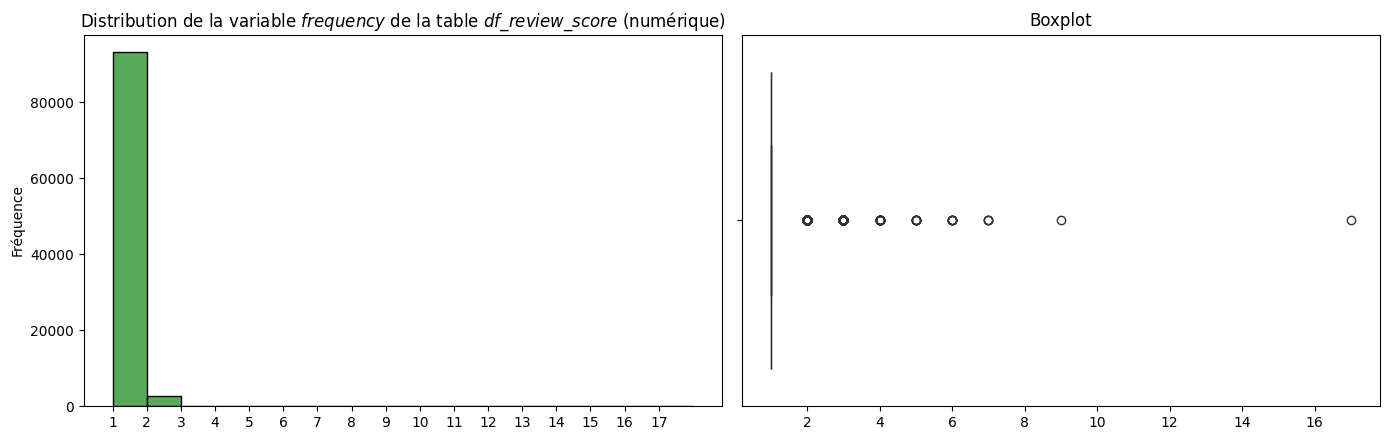

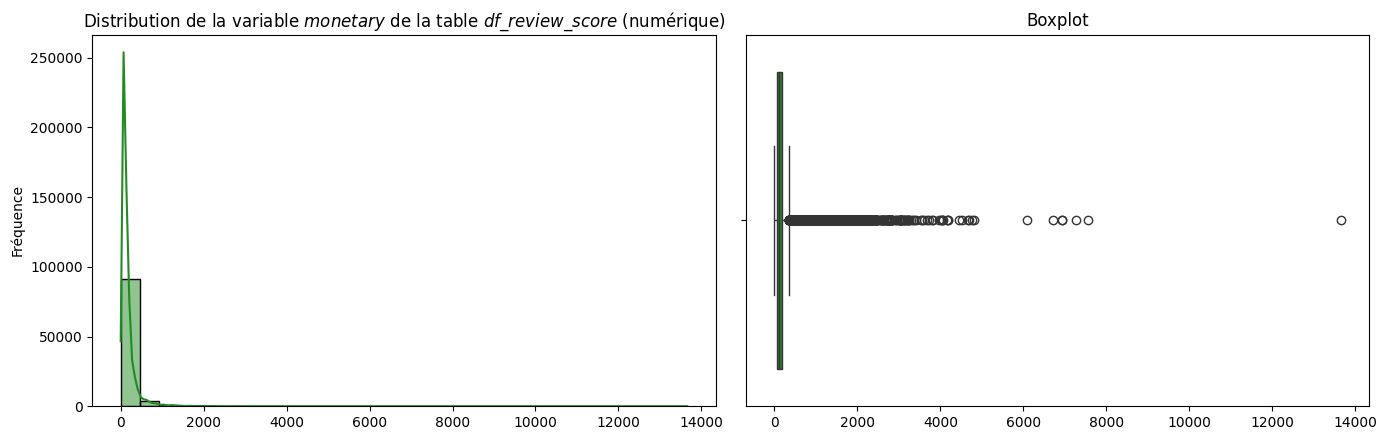

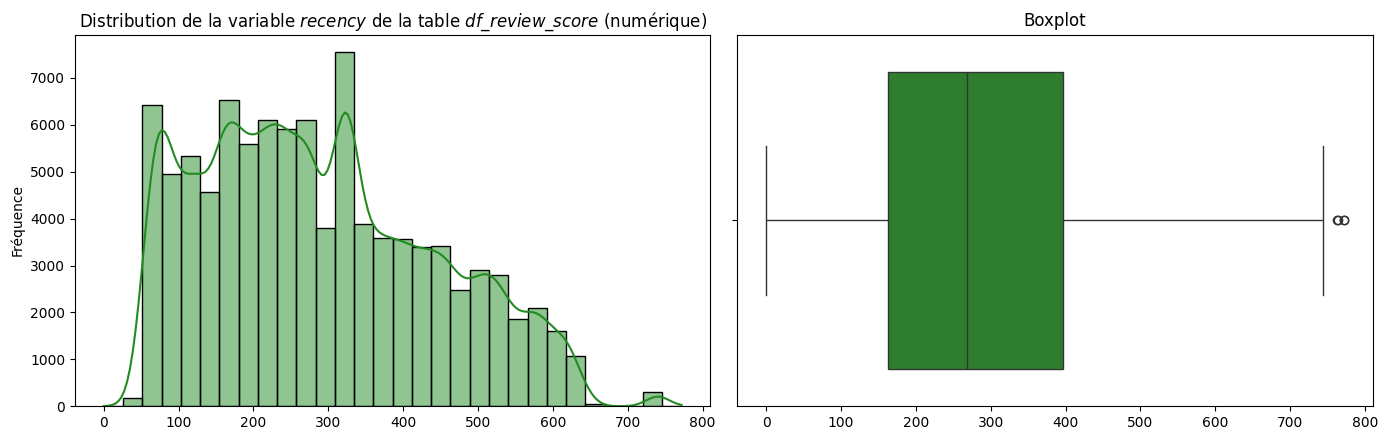

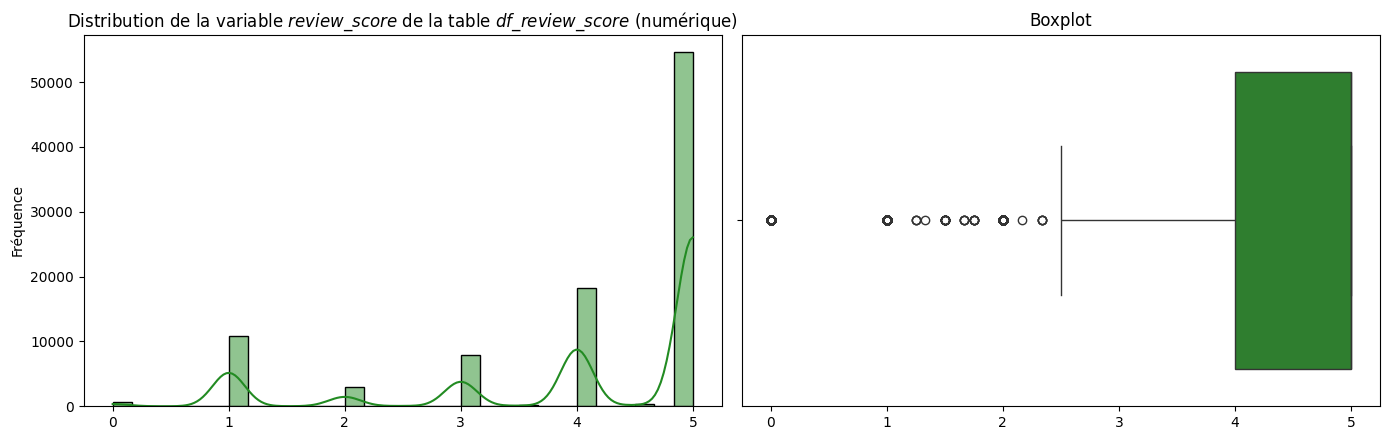

In [50]:
# ==============================
# PROFIL
# ==============================

# --- Profil du dataframe ---
profile_df_review_score = profile_dataframe(
    df_review_score.head(),
    table_name="df_review_score",
    primary_keys=primary_keys
)
display(profile_df_review_score)

# --- Sélection des variables pertinentes pour les distributions ---
distribution_cols = (
    df_review_score
    .select_dtypes(include=["int64", "float64"])
    .loc[:, lambda df: df.nunique() > 2]                 # enlève constantes / quasi constantes
    .loc[:, lambda df: df.isna().mean() < 0.3]           # enlève colonnes trop manquantes
    .columns
    .tolist()
)

# --- Exclure les variables binaires (0/1) ---
distribution_cols = [
    col for col in distribution_cols
    if not set(df_review_score[col].dropna().unique()).issubset({0, 1})
]

# --- Affichage des distributions ---
plot_distributions(
    df_review_score,
    distribution_cols,
    table_name="df_review_score"
)


### **ENTRAÎNEMENT**

In [51]:
# ==============================
# PRÉPARATION DES DONNÉES POUR K-MEANS
# ==============================

# --- Copie de travail ---
df_k_means_v2 = df_review_score.copy()

# --- Exclusion explicite de l'identifiant ---
id_col = 'customer_unique_id'
df_k_means_v2 = df_k_means_v2.drop(columns=[id_col])

# --- Sélection uniquement des colonnes numériques ---
df_k_means_v2 = df_k_means_v2.select_dtypes(include=['int64', 'float64'])

# --- Standardisation des variables RFM ---
scaler = StandardScaler()
df_k_means_v2.loc[:, :] = scaler.fit_transform(df_k_means_v2)

# --- Vérification finale ---
print("Shape df_k_means_v2 :", df_k_means_v2.shape)

profile_df_k_means_v2 = profile_dataframe(
    df_k_means_v2,
    "df_k_means_v2",
    primary_keys=None
)

display(profile_df_k_means_v2)

Shape df_k_means_v2 : (96096, 4)

=== Table : df_k_means_v2 ===
Taille : 96096 lignes × 4 colonnes
Clé primaire : non renseignée

--- Tableau de profil ---


C:\Users\barre\AppData\Local\Temp\ipykernel_15664\2274742139.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.16236828 -0.16236828 -0.16236828 ... -0.16236828 -0.16236828
 -0.16236828]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_k_means_v2.loc[:, :] = scaler.fit_transform(df_k_means_v2)
C:\Users\barre\AppData\Local\Temp\ipykernel_15664\2274742139.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.83262149 -0.81306654  1.93766244 ...  2.14624852 -0.78047497
  1.59219173]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_k_means_v2.loc[:, :] = scaler.fit_transform(df_k_means_v2)


,column,first_value,dtype,detailed_type,n_unique,pct_duplicates,pct_missing,pct_zeros,min,q25,median,q75,max,mean
0,frequency,-0.162368,float64,numérique,9,NaN,0.0,0.0,-0.162368,-0.162368,-0.162368,-0.162368,74.470541,-0.0
1,monetary,-0.100783,float64,numérique,31227,NaN,0.0,0.0,-0.723322,-0.449606,-0.252710,0.076185,59.223294,-0.0
2,recency,-0.832621,float64,numérique,630,NaN,0.0,0.0,-1.875552,-0.813067,-0.128643,0.712219,3.156587,0.0
3,review_score,0.684115,float64,numérique,35,NaN,0.0,0.0,-2.933729,-0.039454,0.684115,0.684115,0.684115,0.0


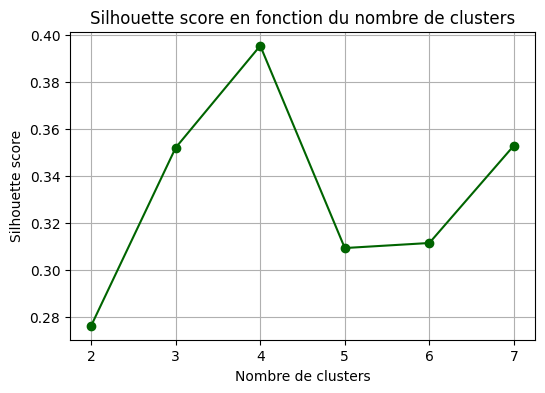

,n_clusters,silhouette_score
0,2,0.276229
1,3,0.352111
2,4,0.395550
3,5,0.309332
4,6,0.311486
5,7,0.352992


Nombre optimal de clusters selon silhouette : 4


In [53]:
# ==============================
# SILOUETTE SCORE
# ==============================

# --- Paramètres ---
range_n_clusters = range(2, 8)
silhouette_scores = []
random_state = 42  # Pour reproductibilité

# Préparer les données pour le clustering (ignore colonne cluster si elle existe)
df_for_clustering = df_k_means_v2.drop(columns=['cluster_init'], errors='ignore')

# --- Calcul des scores silhouette ---
for k in range_n_clusters:
    kmeans = KMeans(n_clusters=k, random_state=random_state)
    labels = kmeans.fit_predict(df_for_clustering)
    score = silhouette_score(df_for_clustering, labels)
    silhouette_scores.append(score)

# --- Affichage de la courbe ---
plt.figure(figsize=(6,4))
plt.plot(
    range_n_clusters,
    silhouette_scores,
    marker='o',
    color='darkgreen'  # <-- couleur vert sapin
)
plt.title("Silhouette score en fonction du nombre de clusters")
plt.xlabel("Nombre de clusters")
plt.ylabel("Silhouette score")
plt.grid(True)
plt.show()

# --- Tableau des résultats ---
results_df = pd.DataFrame({
    "n_clusters": list(range_n_clusters),
    "silhouette_score": silhouette_scores
})
display(results_df)

# --- Meilleur nombre de clusters selon silhouette ---
best_k = results_df.loc[results_df['silhouette_score'].idxmax(), 'n_clusters']
print("Nombre optimal de clusters selon silhouette :", best_k)


n_clusters	silhouette_score

0	2	0.276229

1	3	0.352111

2	4	0.395550

3	5	0.309332

4	6	0.311486

5	7	0.352992

Nombre optimal de clusters selon silhouette : 4

In [71]:
# ==============================
# K-MEANS À 4 CLUSTERS
# ==============================

n_clusters_4 = 4
random_state = 42

# --- Fit KMeans 4 clusters ---
kmeans_rev_score_4_clusters = KMeans(n_clusters=n_clusters_4, random_state=random_state)
df_k_means_v2['cluster'] = kmeans_rev_score_4_clusters.fit_predict(df_k_means_v2.drop(columns=['cluster_init'], errors='ignore'))

# --- Vérifications quantitatives ---
inertia = kmeans_rev_score_4_clusters.inertia_
sil_score = silhouette_score(df_k_means_v2.drop(columns=['cluster_init', 'cluster'], errors='ignore'), 
                             df_k_means_v2['cluster'])

print(f"Inertia (somme des distances au centre) : {inertia:.2f}")
print(f"Silhouette score : {sil_score:.3f}")

# --- Distribution des clusters ---
print("\nDistribution des clusters :")
print(df_k_means_v2['cluster'].value_counts())

KeyboardInterrupt: 

In [55]:
# ==============================
# SAUVEGARDE DATAFRAME ET MODELE K-MEANS
# ==============================

# chemin raw string
path_data = r"C:\Users\barre\Documents\Pro\Reconversion_professionnelle\Formations\Data_Scientist_by_Openclassrooms\P05\data"

# sauvegarde du DataFrame
df_k_means_v2.to_csv(f"{path_data}/df_k_means_v2.csv", index=False)

# sauvegarde du modèle KMeans
joblib.dump(kmeans_rev_score_4_clusters, f"{path_data}/kmeans_rev_score_4_clusters.joblib")

['C:\\Users\\barre\\Documents\\Pro\\Reconversion_professionnelle\\Formations\\Data_Scientist_by_Openclassrooms\\P05\\data/kmeans_rev_score_4_clusters.joblib']

In [72]:
# ==============================
# RECHARGEMENT DATAFRAME ET MODELE K-MEANS
# ==============================

path_data = r"C:\Users\barre\Documents\Pro\Reconversion_professionnelle\Formations\Data_Scientist_by_Openclassrooms\P05\data"

# rechargement du DataFrame
df_k_means_v2 = pd.read_csv(f"{path_data}/df_k_means_v2.csv")

# rechargement du modèle
kmeans_rev_score_4_clusters = joblib.load(f"{path_data}/kmeans_rev_score_4_clusters.joblib")

In [ ]:
# # ==============================
# # K-MEANS À 7 CLUSTERS
# # ==============================

# n_clusters_7 = 7
# random_state = 42

# # --- Fit KMeans 7 clusters ---
# kmeans_rev_score_7_clusters = KMeans(n_clusters=n_clusters_7, random_state=random_state)
# df_k_means_v2['cluster'] = kmeans_rev_score_7_clusters.fit_predict(df_k_means_v2.drop(columns=['cluster_init'], errors='ignore'))

# # --- Vérifications quantitatives ---
# inertia = kmeans_rev_score_7_clusters.inertia_
# sil_score = silhouette_score(df_k_means_v2.drop(columns=['cluster_init', 'cluster'], errors='ignore'), 
#                              df_k_means_v2['cluster'])

# print(f"Inertia (somme des distances au centre) : {inertia:.2f}")
# print(f"Silhouette score : {sil_score:.3f}")

# # --- Distribution des clusters ---
# print("\nDistribution des clusters :")
# print(df_k_means_v2['cluster'].value_counts())

Inertia (somme des distances au centre) : 109722.29
Silhouette score : 0.289

Distribution des clusters :
cluster
1    31273
0    21899
5    19833
2    16729
4     2975
3     2963
6      424
Name: count, dtype: int64


Inertia (somme des distances au centre) : 109722.29

Silhouette score : 0.289

Distribution des clusters :

cluster

1    31273

0    21899

5    19833

2    16729

4     2975

3     2963

6      424

Name: count, dtype: int64

### **INTERPRÉTATION DES CLUSTERS**


=== Table : df_k_means_v2 ===
Taille : 96096 lignes × 5 colonnes
Clé primaire : non renseignée

--- Tableau de profil ---


,column,first_value,dtype,detailed_type,n_unique,pct_duplicates,pct_missing,pct_zeros,min,q25,median,q75,max,mean
0,frequency,-0.162368,float64,numérique,9,NaN,0.0,0.00,-0.162368,-0.162368,-0.162368,-0.162368,74.470541,-0.00
1,monetary,-0.100783,float64,numérique,30586,NaN,0.0,0.00,-0.723322,-0.449606,-0.252710,0.076185,59.223294,-0.00
2,recency,-0.832621,float64,numérique,630,NaN,0.0,0.00,-1.875552,-0.813067,-0.128643,0.712219,3.156587,0.00
3,review_score,0.684115,float64,numérique,35,NaN,0.0,0.00,-2.933729,-0.039454,0.684115,0.684115,0.684115,0.00
4,cluster,0.000000,int64,numérique,4,NaN,0.0,44.99,0.000000,0.000000,1.000000,1.000000,3.000000,0.79


,recency,monetary,frequency,review_score
cluster,,,,
0,-0.76,-0.05,-0.16,0.43
1,1.00,-0.04,-0.16,0.41
2,0.04,0.06,-0.16,-1.86
3,-0.13,0.72,5.03,0.03


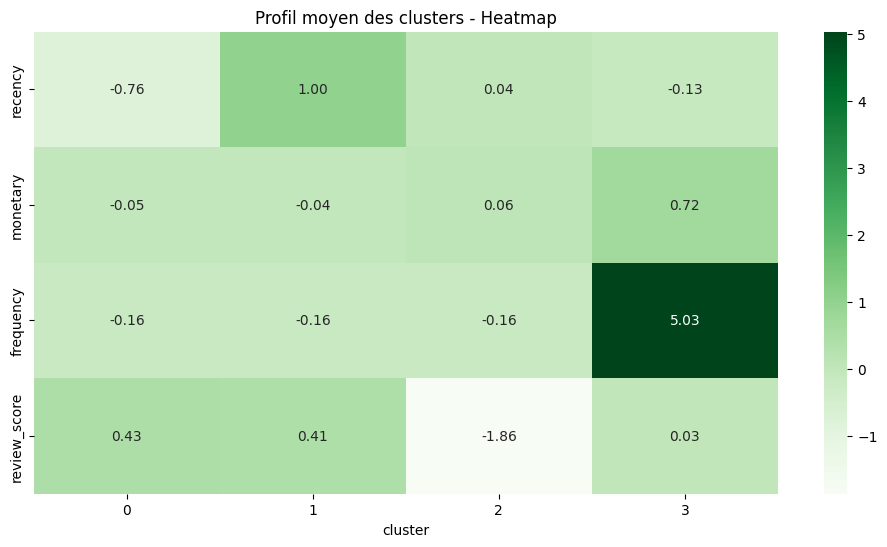

In [ ]:
# ==============================
# 1. PROFIL DU DATAFRAME
# ==============================

# Profil complet du dataframe
df_profile = profile_dataframe(df_k_means_v2, table_name="df_k_means_v2")
display(df_profile)

# Profil moyen par cluster pour toutes les variables continues
cols_continuous = ['recency', 'monetary', 'frequency', 'review_score']
cols_continuous = [c for c in cols_continuous if c in df_k_means_v2.columns]

cluster_means = df_k_means_v2.groupby('cluster')[cols_continuous].mean().round(2)
display(cluster_means)

# Heatmap du profil moyen
plt.figure(figsize=(12, 6))
sns.heatmap(cluster_means.T, annot=True, fmt=".2f", cmap="Greens")
plt.title("Profil moyen des clusters - Heatmap")
plt.show()


,cluster,nb_clients
0,0,43230
1,1,32558
2,2,17301
3,3,3007


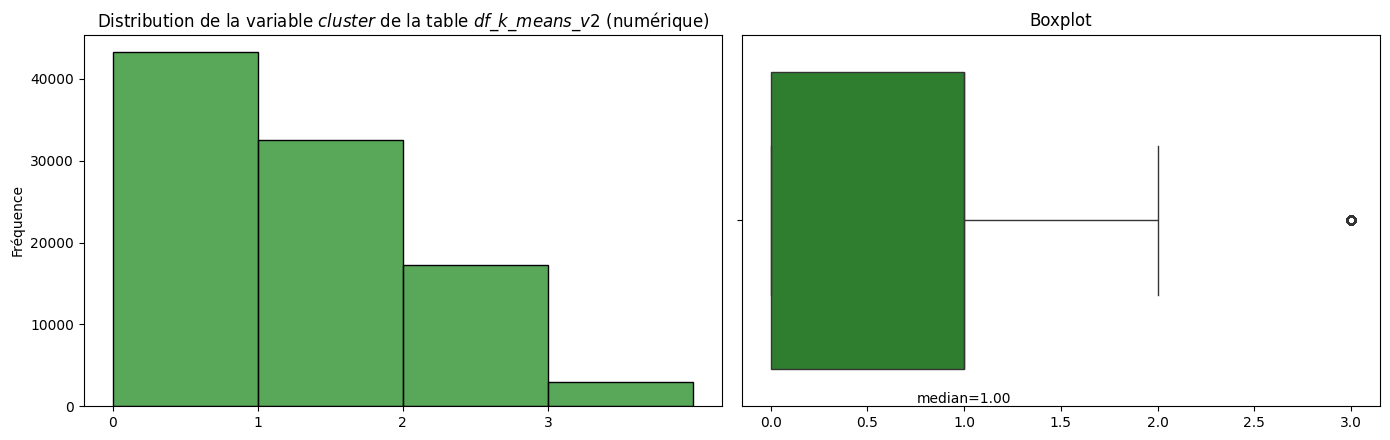

In [ ]:
# ==============================
# 2. RÉPARTITION DES CLIENTS
# ==============================

# Tableau chiffré des effectifs
cluster_counts = df_k_means_v2['cluster'].value_counts().sort_index().reset_index()
cluster_counts.columns = ['cluster', 'nb_clients']
display(cluster_counts)

# Barplot forestgreen
plot_distributions(
    df=df_k_means_v2,
    columns='cluster',
    table_name="df_k_means_v2",
    show_values=True
)


cluster,0,1,2,3
count,43230.00,32558.00,17301.00,3007.00
mean,-0.76,1.00,0.04,-0.13
std,0.47,0.62,0.88,0.95
min,-1.59,0.07,-1.88,-1.88
25%,-1.17,0.46,-0.50,-0.89
50%,-0.77,0.93,-0.08,-0.26
75%,-0.37,1.47,0.45,0.52
max,0.13,2.97,3.16,2.95


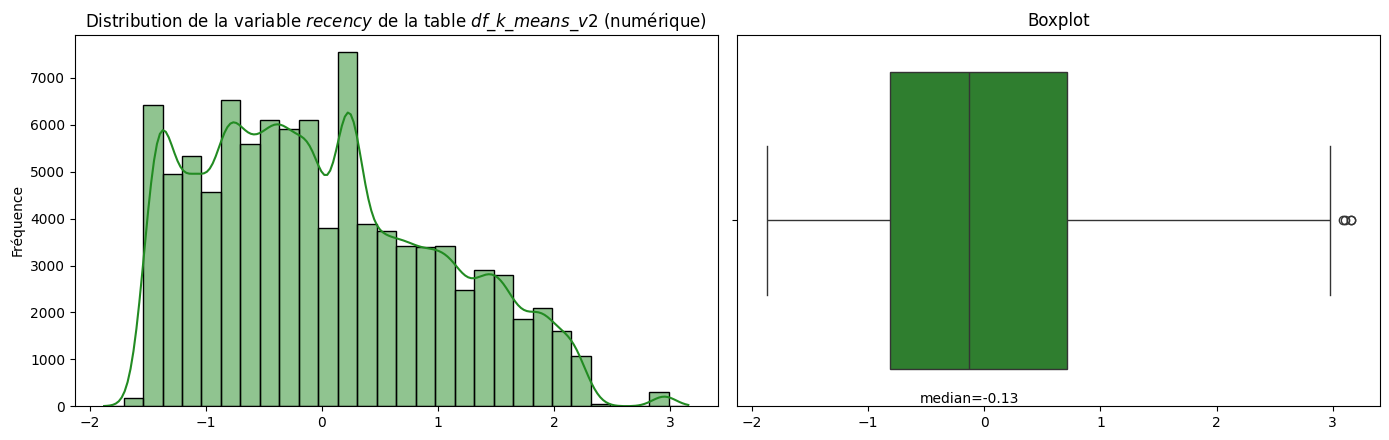

cluster,0,1,2,3
count,43230.00,32558.00,17301.00,3007.00
mean,-0.05,-0.04,0.06,0.72
std,0.87,0.90,1.08,2.24
min,-0.72,-0.72,-0.72,-0.72
25%,-0.46,-0.46,-0.44,-0.09
50%,-0.27,-0.28,-0.23,0.26
75%,0.03,0.03,0.14,0.86
max,17.59,17.01,20.38,59.22


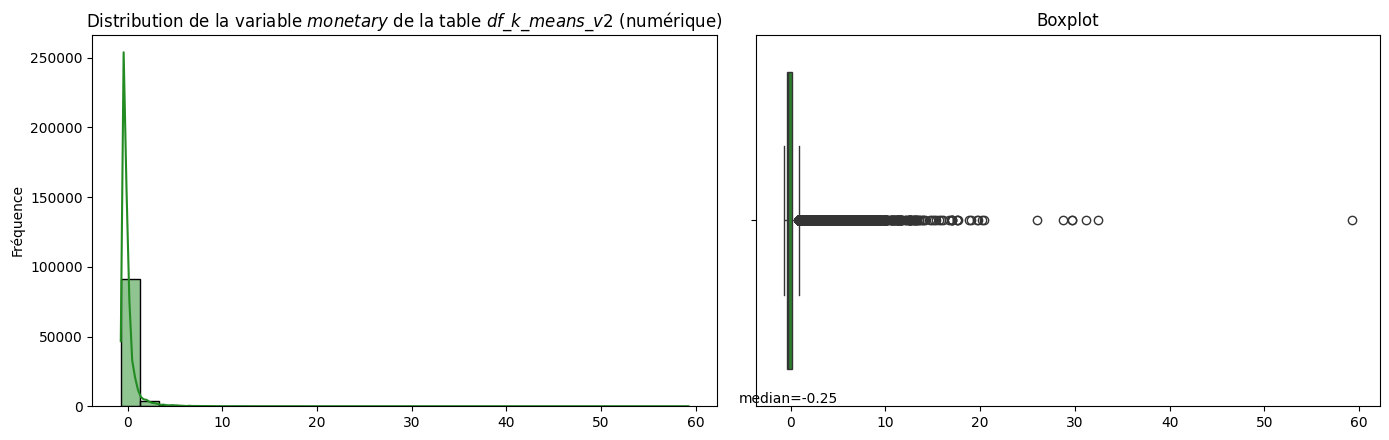

cluster,0,1,2,3
count,43230.00,32558.00,17301.00,3007.00
mean,-0.16,-0.16,-0.16,5.03
std,0.00,0.00,0.00,2.42
min,-0.16,-0.16,-0.16,-0.16
25%,-0.16,-0.16,-0.16,4.50
50%,-0.16,-0.16,-0.16,4.50
75%,-0.16,-0.16,-0.16,4.50
max,-0.16,-0.16,-0.16,74.47


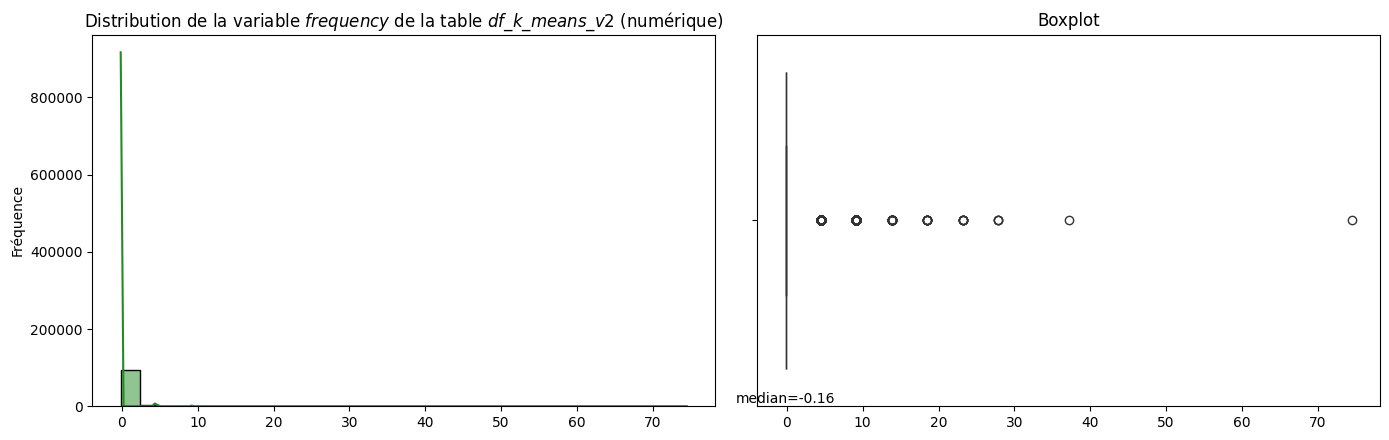

cluster,0,1,2,3
count,43230.00,32558.00,17301.00,3007.00
mean,0.43,0.41,-1.86,0.03
std,0.42,0.44,0.60,0.85
min,-0.76,-1.49,-2.93,-2.93
25%,-0.04,-0.04,-2.21,-0.40
50%,0.68,0.68,-2.21,0.32
75%,0.68,0.68,-1.49,0.68
max,0.68,0.68,-0.76,0.68


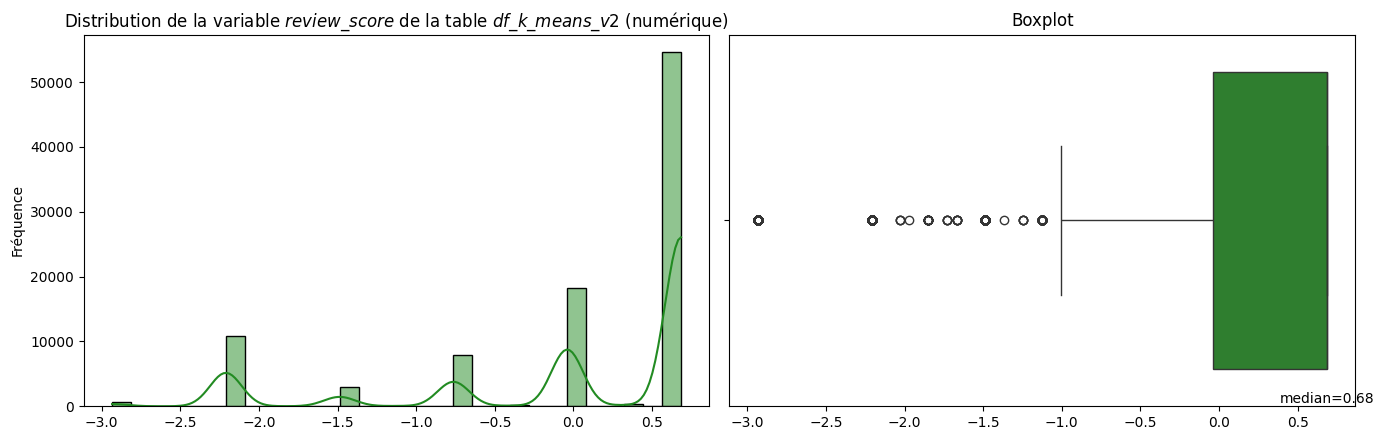

In [ ]:
# ==============================
# 3. DISTRIBUTIONS DES VARIABLES
# ==============================

features_to_plot = ['recency', 'monetary', 'frequency', 'review_score']
features_to_plot = [f for f in features_to_plot if f in df_k_means_v2.columns]

# Boucle boxplots + tableau chiffré
for feature in features_to_plot:
    # Tableau descriptif par cluster
    desc = df_k_means_v2.groupby('cluster')[feature].describe().T.round(2)
    display(desc)

    # Boxplot
    plot_distributions(
        df=df_k_means_v2,
        columns=feature,
        table_name="df_k_means_v2",
        show_values=True
    )


rectifier/supprimer l'acp

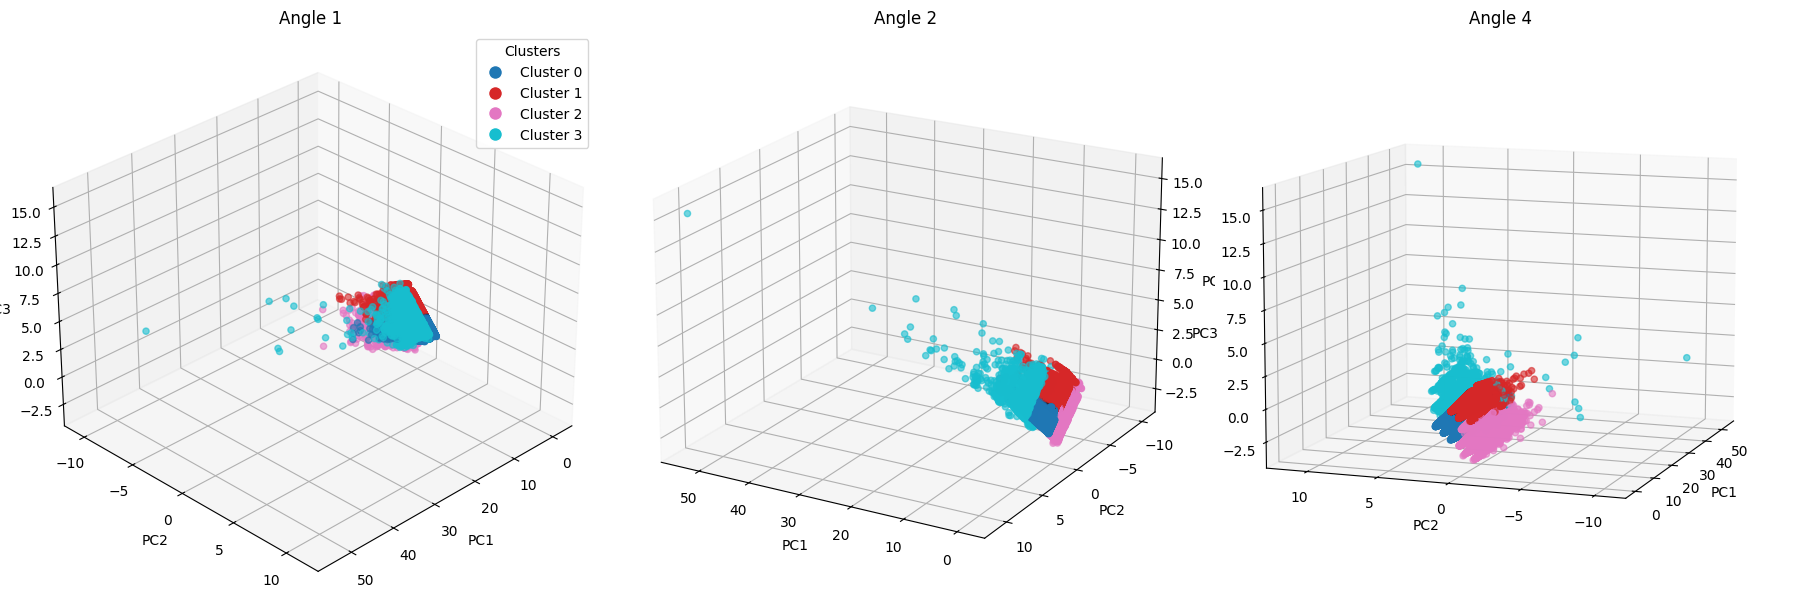

,composante,variance_expliquee,variance_cumulee
0,PC1,0.282,0.282
1,PC2,0.259,0.541
2,PC3,0.242,0.783


,PC1,PC2,PC3
frequency,0.689,0.140,0.214
monetary,0.700,-0.143,0.049
recency,-0.139,-0.663,0.734
review_score,-0.123,0.721,0.643


,PC1,PC2,PC3
cluster,,,
0,-0.09,0.80,-0.32
1,-0.33,-0.38,0.96
2,0.16,-1.40,-1.20
3,3.98,0.71,1.04


In [91]:
# ==============================
# 4. PCA 3D + TABLEAUX CHIFFRÉS
# ==============================

X = df_k_means_v2.drop(columns=['cluster', 'cluster_init'], errors='ignore')        # Variables utilisées

# --- PCA ---
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)

# --- VISUALISATION 3D ---
categorical_cmap = plt.cm.tab10

angles = [
    (30, 45, "Angle 1"),
    (20, 120, "Angle 2"),
    (10, 200, "Angle 4")
]

fig = plt.figure(figsize=(18,6))

for i, (elev, azim, title) in enumerate(angles, start=1):
    ax = fig.add_subplot(1, 3, i, projection='3d')
    
    scatter = ax.scatter(
        X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
        c=df_k_means_v2['cluster'],
        cmap=categorical_cmap,
        alpha=0.6
    )
    
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_zlabel("PC3")
    ax.set_title(title)
    ax.view_init(elev=elev, azim=azim)

    if i == 1:
        unique_labels = np.sort(df_k_means_v2['cluster'].unique())
        legend_elements = [
            Line2D(
                [0], [0],
                marker='o',
                color='w',
                markerfacecolor=categorical_cmap(j / (len(unique_labels)-1)),
                label=f"Cluster {l}",
                markersize=10
            )
            for j, l in enumerate(unique_labels)
        ]
        ax.legend(handles=legend_elements, title="Clusters")

plt.tight_layout()
plt.show()

# --- TABLEAUX CHIFFRÉS ---

# 1. Variance expliquée
pca_variance = pd.DataFrame({
    "composante": ["PC1", "PC2", "PC3"],
    "variance_expliquee": pca.explained_variance_ratio_,
    "variance_cumulee": np.cumsum(pca.explained_variance_ratio_)
}).round(3)

display(pca_variance)

# 2. Loadings (contribution des variables)
loadings = pd.DataFrame(
    pca.components_.T,
    index=X.columns,
    columns=["PC1", "PC2", "PC3"]
).round(3)

display(loadings)

# 3. Centres des clusters dans l’espace PCA
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2", "PC3"])
df_pca["cluster"] = df_k_means_v2["cluster"].values

cluster_centers_pca = (
    df_pca
    .groupby("cluster")[["PC1", "PC2", "PC3"]]
    .mean()
    .round(2)
)

display(cluster_centers_pca)


### **ANALYSE DU CLUSTERING K-MEANS V2 (RFM + REVIEW_SCORE)**

____
**STRUCTURE DU JEU DE DONNÉES**

| Élément | Valeur |
|------|------|
| Taille du jeu de données | 96 096 lignes (clients) × 5 colonnes (variables) |
| Variables quantitatives | frequency, monetary, recency, review_score |
| Variable de segmentation | cluster |
| Standardisation | oui |
| Valeurs manquantes | 0 % |
| Zéros | 0 % (hors cluster) |
| Nombre de clusters | 4 |

Variables utilisées
- `frequency` : intensité d’achat
- `monetary` : valeur générée
- `recency` : récence d’achat (plus bas = plus récent)
- `review_score` : satisfaction client

____
**RÉPARTITION DES CLUSTERS**

| Cluster | Nb clients | Part |
|------|-----------|------|
| 0 | 43 230 | 45.0 % |
| 1 | 32 558 | 33.9 % |
| 2 | 17 301 | 18.0 % |
| 3 | 3 007 | 3.1 % |

→  Segmentation très déséquilibrée  
Un petit cluster à très forte valeur (cluster 3) et deux clusters majoritaires à faible intensité d’achat.

____
**PROFIL MOYEN DES CLUSTERS (VARIABLES STANDARDISÉES)**

| Cluster | Recency | Monetary | Frequency | Review_score |
|------|--------|----------|-----------|--------------|
| 0 | **−0.76** | −0.05 | −0.16 | **0.43** |
| 1 | **1.00** | −0.04 | −0.16 | **0.41** |
| 2 | 0.04 | 0.06 | −0.16 | **−1.86** |
| 3 | −0.13 | **0.72** | **5.03** | 0.03 |

____
**INTERPRÉTATION MÉTIER DES CLUSTERS**

**Cluster 0 — Clients récents satisfaits (45 %)**
- Achats récents
- Faible valeur et faible fréquence
- Bonne satisfaction
→ Clients occasionnels récents, potentiel de montée en gamme

**Cluster 1 — Clients anciens satisfaits mais inactifs (34 %)**
- Achats anciens
- Faible valeur et fréquence
- Satisfaction correcte
→ Clients **à réactiver**

**Cluster 2 — Clients insatisfaits (18 %)**
- Récence moyenne
- Valeur faible à moyenne
- **Très faible satisfaction**
→ Segment à risque, prioritaire pour actions correctives

**Cluster 3 — Clients premium (3 %)**
- Très forte fréquence
- Forte valeur
- Satisfaction neutre
→ **Cœur de business**, clients fidèles et rentables

____
**ANALYSE DÉTAILLÉE PAR VARIABLE**

**Recency**
- Cluster 0 : clients les plus récents
- Cluster 1 : clients les plus anciens
- Forte dispersion dans les clusters 2 et 3

**Monetary**
- Cluster 3 se distingue nettement (valeur maximale très élevée)
- Les autres clusters restent proches de la moyenne

**Frequency**
- Variable **structurante du cluster 3**
- Les clusters 0, 1 et 2 ont un comportement quasi identique (fréquence minimale)

**Review_score**
- Cluster 2 fortement négatif → insatisfaction marquée
- Clusters 0 et 1 bien notés
- Cluster 3 neutre : performance business ≠ satisfaction maximale

____
**ANALYSE PCA**

**Variance expliquée**
| Composante | Variance | Cumul |
|---------|---------|-------|
| PC1 | 28.2 % | 28.2 % |
| PC2 | 25.9 % | 54.1 % |
| PC3 | 24.2 % | **78.3 %** |

→ PCA robuste, bonne représentation des clusters

**Contribution des variables**

| Variable | PC1 | PC2 | PC3 |
|-------|-----|-----|-----|
| frequency | **0.689** | 0.140 | 0.214 |
| monetary | **0.700** | −0.143 | 0.049 |
| recency | −0.139 | **−0.663** | **0.734** |
| review_score | −0.123 | **0.721** | **0.643** |

- **PC1** : valeur business (frequency + monetary)
- **PC2** : satisfaction vs récence
- **PC3** : comportement récent + perception client

**Position moyenne des clusters dans l’espace PCA**

| Cluster | PC1 | PC2 | PC3 |
|------|-----|-----|-----|
| 0 | −0.09 | **0.80** | −0.32 |
| 1 | −0.33 | −0.38 | **0.96** |
| 2 | 0.16 | **−1.40** | **−1.20** |
| 3 | **3.98** | 0.71 | **1.04** |

→ Séparation nette des clusters, cohérente avec l’interprétation métier

____
**CONCLUSION GLOBALE**

- Clustering **cohérent, interprétable et pertinent**
- Segmentation claire entre :
  - clients premium
  - clients occasionnels
  - clients à réactiver
  - clients insatisfaits
- L’ajout du `review_score` apporte une **dimension qualitative clé**
- PCA confirme la structure et la séparation des groupes

→ Modèle exploitable pour **stratégie marketing ciblée et priorisation business**


### **COMPARAISON DES 2 VERSIONS DE K-MEANS V2 : SANS ET AVEC REVIEW_SCORE**

___
**STRUCTURE ET VARIABLES**

| Aspect | K-means v1 | K-means v2 |
|--------|------------|------------|
| Nombre de variables | 3 (frequency, monetary, recency) | 4 (frequency, monetary, recency, review_score) |
| Nombre de clusters | 2 | 4 |
| Standardisation | Oui | Oui |

- L’ajout de `review_score` dans la v2 permet d’intégrer une dimension qualitative (satisfaction client) qui n’existait pas dans la v1.  
- La v1 se concentre uniquement sur le comportement d’achat et la valeur, tandis que la v2 capture également la perception client.

___
**SEGMENTATION**

| Aspect | K-means v1 | K-means v2 |
|--------|------------|------------|
| Cluster majoritaire | 97 % | 45 % |
| Cluster premium | 3 % | 3 % |
| Nombre de clusters intermédiaires | 0 | 2 (clients à réactiver, clients insatisfaits) |
| Équilibre | Très déséquilibré | Plus nuancé, mais toujours déséquilibré |

- La v2 permet d’identifier des segments intermédiaires, invisibles dans la v1, grâce à l’inclusion de `review_score`.  
- Le cluster premium reste similaire en taille et profil dans les deux versions.

___
**INTERPRÉTABILITÉ MÉTIER**

- **V1** : distinction simple entre clients majoritaires peu actifs et clients premium → utile pour repérer le cœur de business, mais insuffisant pour stratégie marketing segmentée.  
- **V2** : segmentation plus fine permet d’identifier :
  - clients à réactiver (anciens mais satisfaits)  
  - clients insatisfaits (risque potentiel)  
  - clients occasionnels récents  
  → Facilite des actions marketing ciblées et prioritaires selon la valeur et la satisfaction.

___
**PCA ET STRUCTURE DES CLUSTERS**

| Aspect | K-means v1 | K-means v2 |
|--------|------------|------------|
| Variance expliquée cumulative | 100 % (3 composantes) | 78.3 % (3 composantes) |
| Séparation dans l’espace PCA | Nette pour 2 clusters seulement | Bonne séparation de 4 clusters, plus riche en nuances |
| Variables contributives | Frequency et monetary dominent PC1 | Frequency + monetary dominent PC1, review_score apporte une dimension PC2/PC3 |

- La v2 enrichit la structure PCA : elle confirme la séparation des clusters mais permet de visualiser la satisfaction client comme une dimension additionnelle.

___
**CONCLUSIONS COMPARATIVES**

- V1 **SANS** review_score :
  - Simplicité et forte distinction du cluster premium  
  - Limité pour détecter les nuances de comportement ou insatisfaction  
  - Adapté à une analyse rapide de valeur/fidélité  

- V2 **AVEC** review_score :
  - Segmentation plus riche et interprétable  
  - Identification de segments stratégiques (à réactiver, insatisfaits)  
  - PCA et clustering cohérents, plus utiles pour priorisation marketing et actions ciblées  

**→ Synthèse** : L’ajout de `review_score` transforme le clustering de simple distinction "premium / non-premium" en une segmentation exploitable pour la stratégie marketing, tout en conservant l’identification claire du cœur de business.


DBSCAN

agglomerative clustering > a faire sur un échantillon (15/25%) si ça prend trop de temps

MAINTENANCE
Si nouveaux clients ou comportements différents des anciens > clustering obsolete
- tester sur une fréquence de réentrainement du k-means toutes les semaines
- faire un ARI score pour chaque nouvelle version des k-means VS k-means initial
- on teste par pas de 7 jours → ARI <0.8
- on en concluera la périodicité de réentrainement pour la maintenance

1. mettre à jour le nb de clusters de la V1
2. ne pas faire de PCA
3. changer les hyperparamétres, en plus du silouette score pour valider le nb de clusters (CE3 et CE4)
3. mettre à jour les analyses avec nouveau nb de cluster + choix des hyperparamétres
4. tester avec DBSCAn et agglomerative clustering
5. faire la maintenance